In [1]:
# upload a file
from google.colab import files
uploaded = files.upload()

Saving Zoo.csv to Zoo.csv


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


In [3]:
data = pd.read_csv('/content/Zoo.csv')

In [4]:
data.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [5]:
data.rename(columns={'animal name': 'animal_name'}, inplace=True)

In [6]:
data.animal_name.nunique()

100

In [7]:
data.dtypes

,0
animal_name,object
hair,int64
feathers,int64
eggs,int64
milk,int64
airborne,int64
aquatic,int64
predator,int64
toothed,int64
backbone,int64


In [8]:
data.shape

(101, 18)

In [9]:
data[::]

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [10]:
data = data.iloc[:,1:]

In [11]:
data.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [12]:
data.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [24]:
# Check for missing values
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
hair        0
feathers    0
eggs        0
milk        0
airborne    0
aquatic     0
predator    0
toothed     0
backbone    0
breathes    0
venomous    0
fins        0
legs        0
tail        0
domestic    0
catsize     0
type        0
dtype: int64


In [13]:
data['type'].nunique()

7

In [14]:
for col in data.columns:
  print(col, data[col].nunique())

hair 2
feathers 2
eggs 2
milk 2
airborne 2
aquatic 2
predator 2
toothed 2
backbone 2
breathes 2
venomous 2
fins 2
legs 6
tail 2
domestic 2
catsize 2
type 7


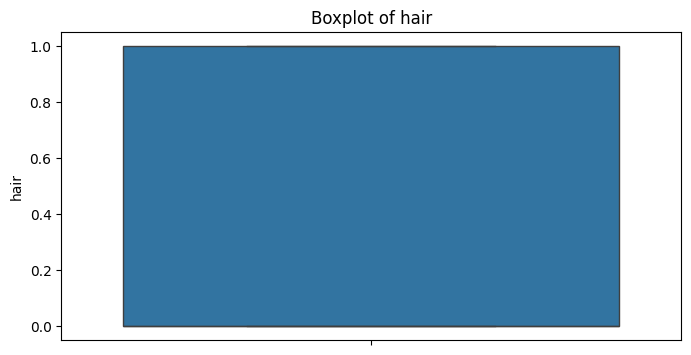

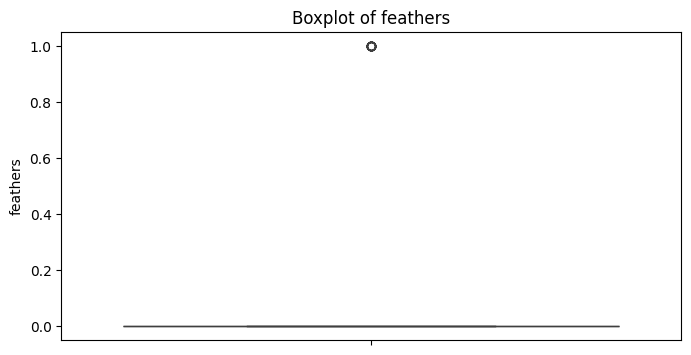

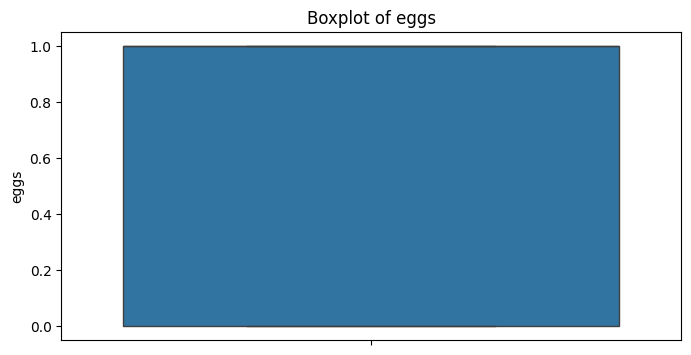

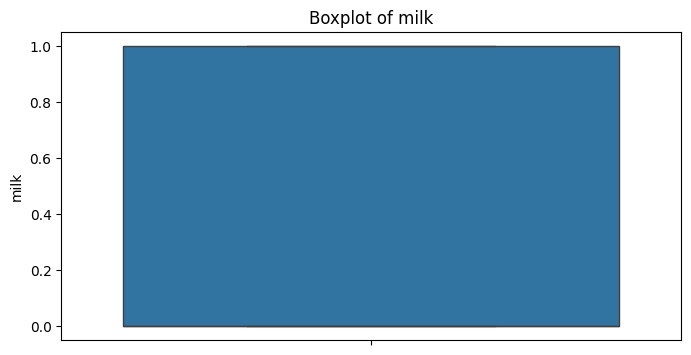

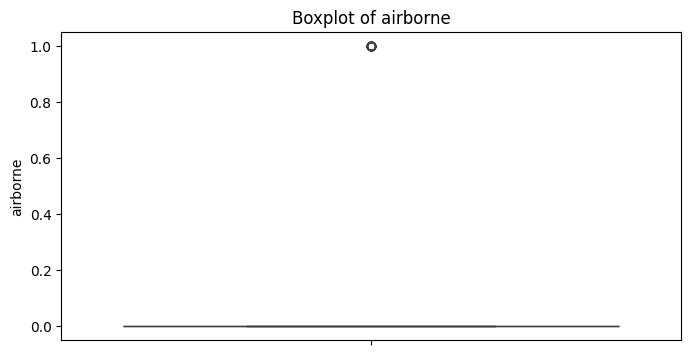

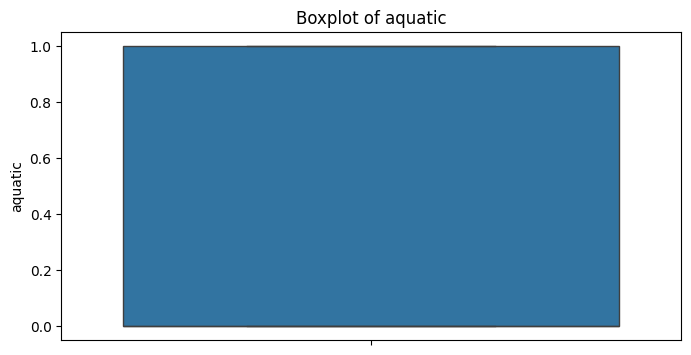

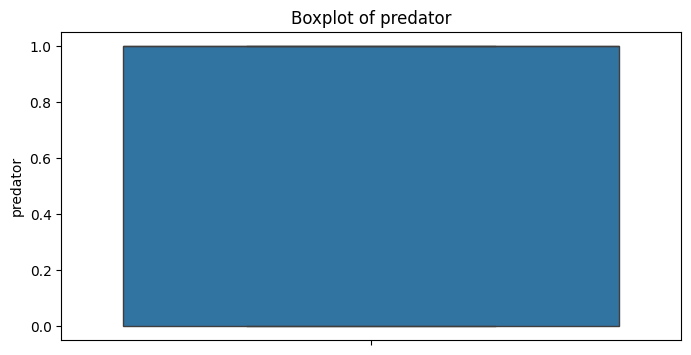

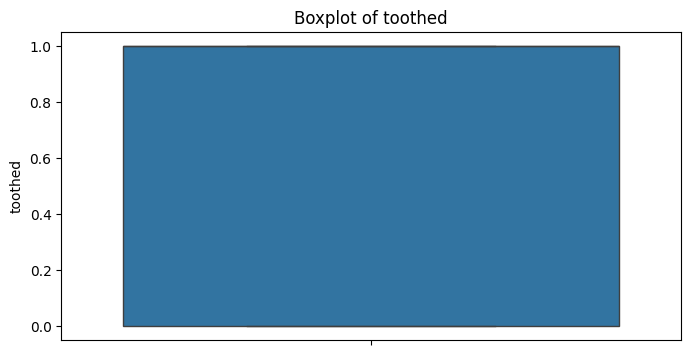

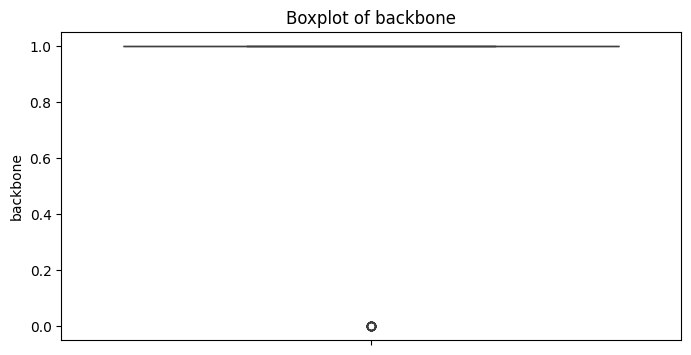

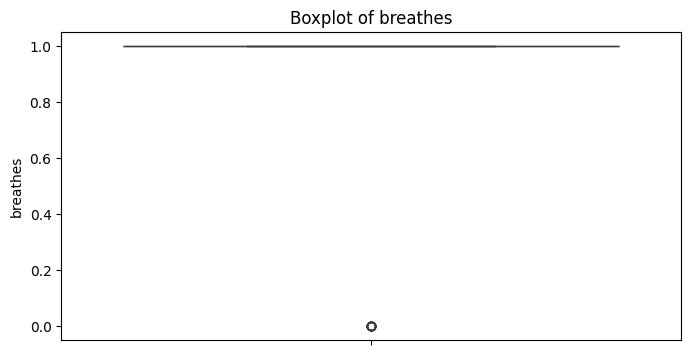

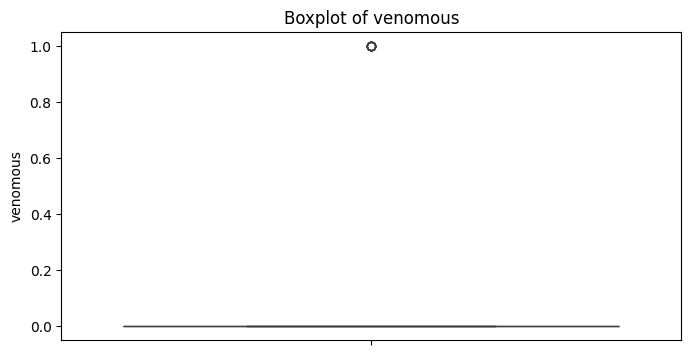

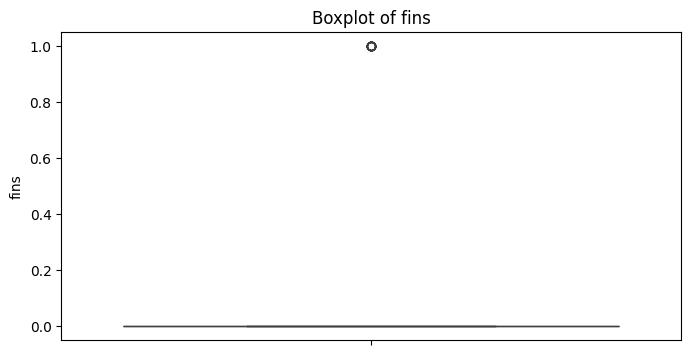

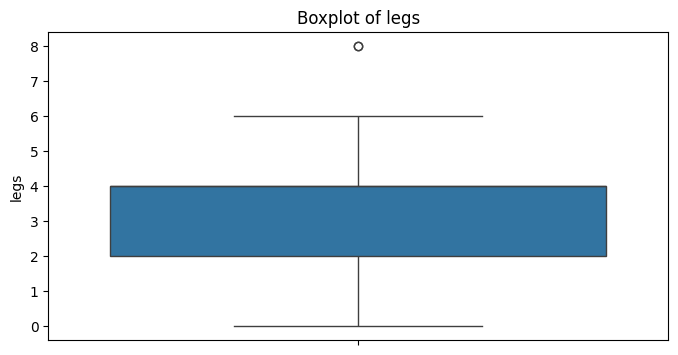

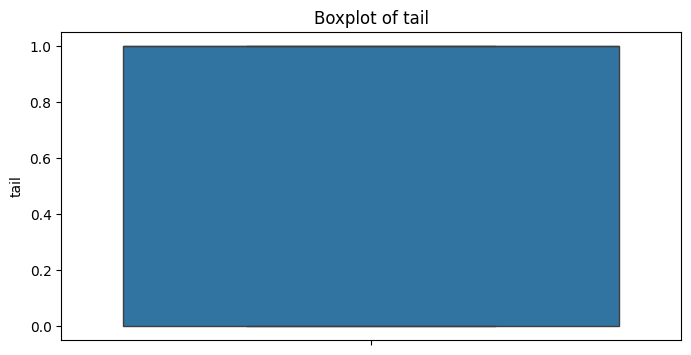

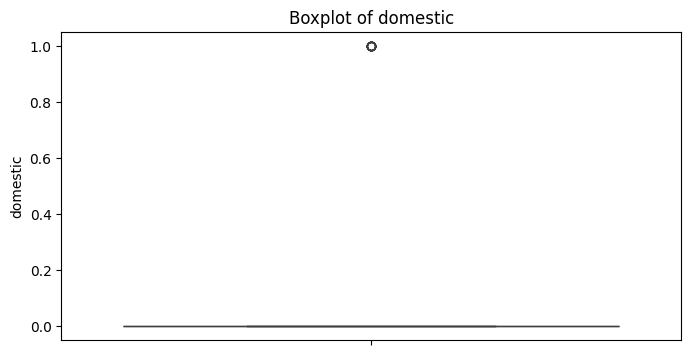

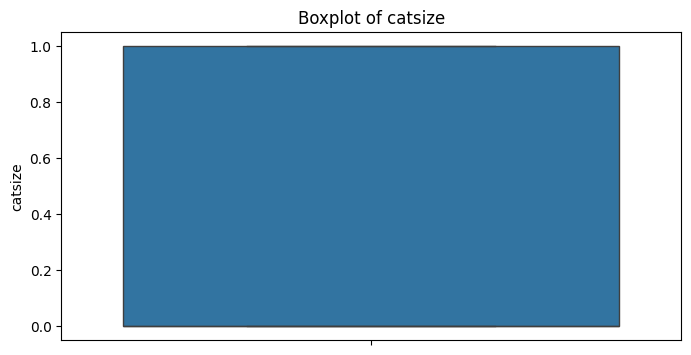

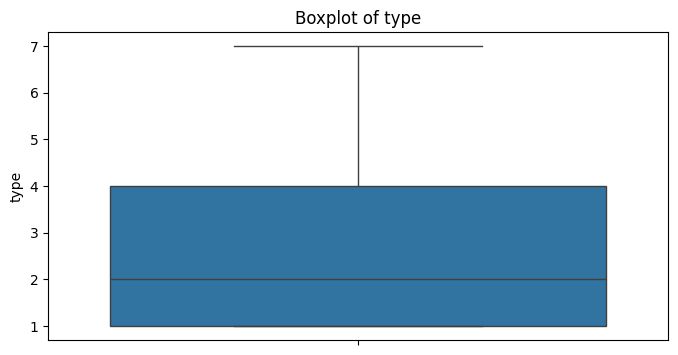

In [15]:
for col in data.columns:
  plt.figure(figsize=(8, 4))
  sns.boxplot(y=data[col])
  plt.title(f'Boxplot of {col}')
  plt.ylabel(col)
  plt.show()

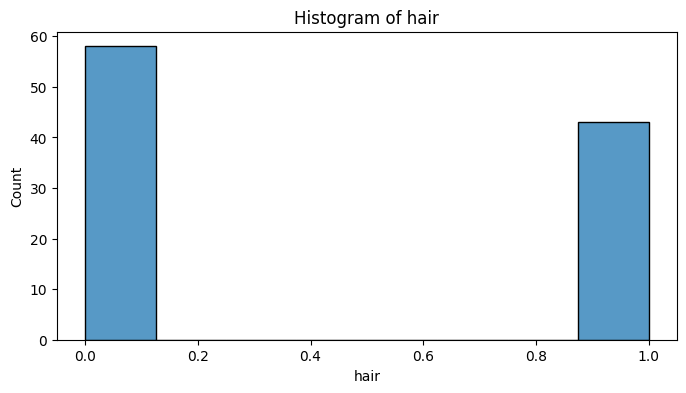

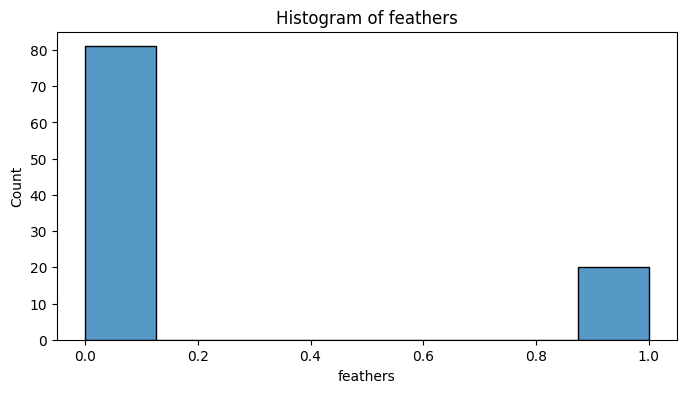

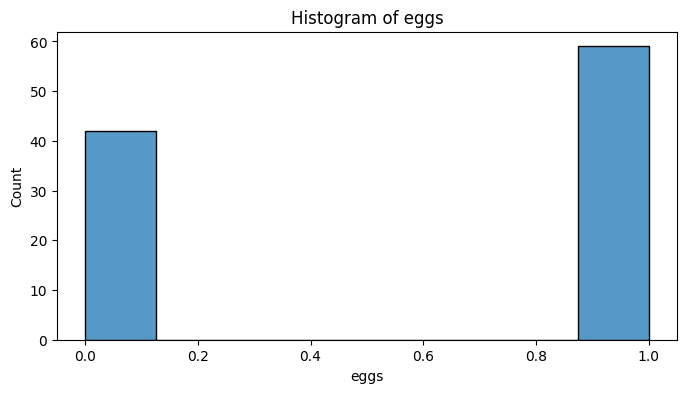

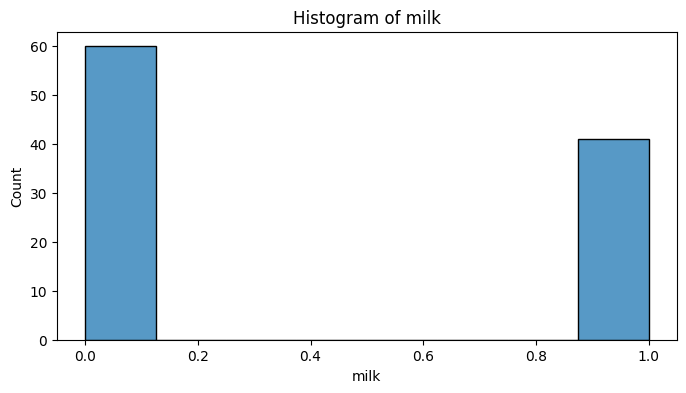

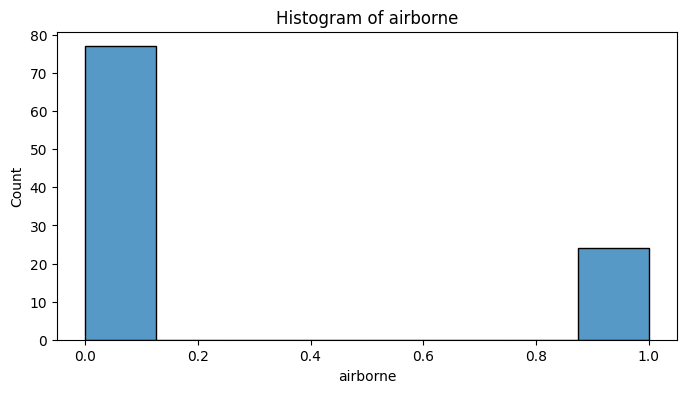

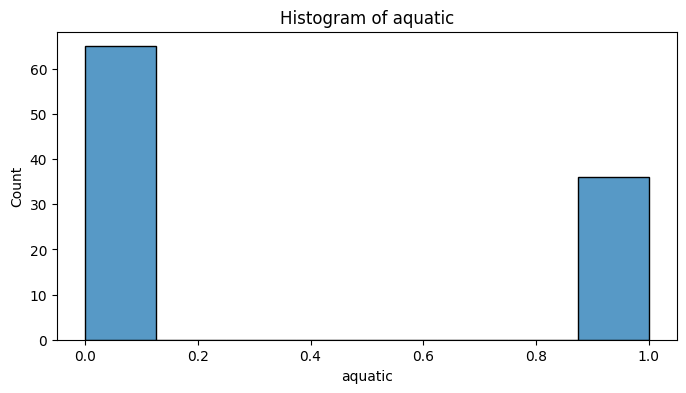

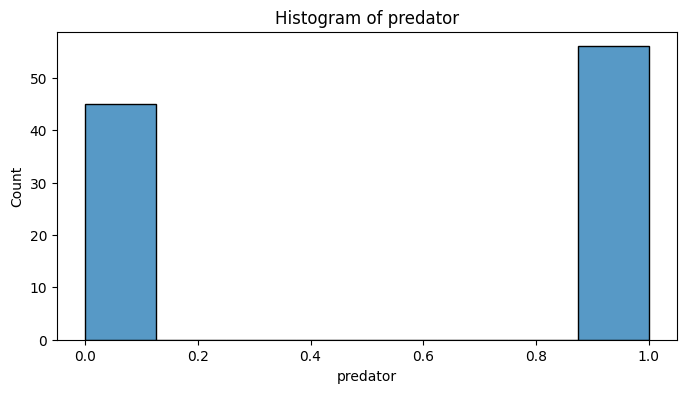

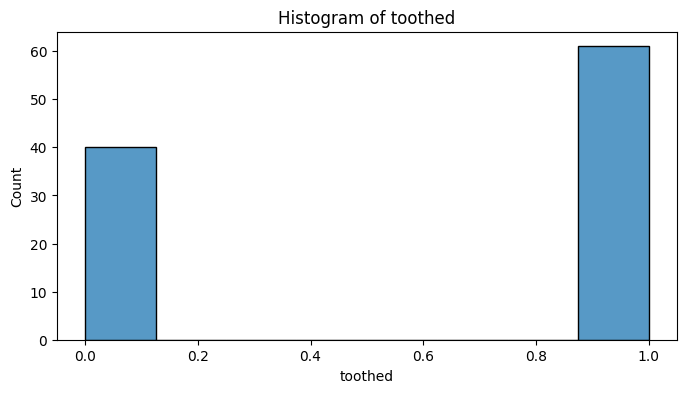

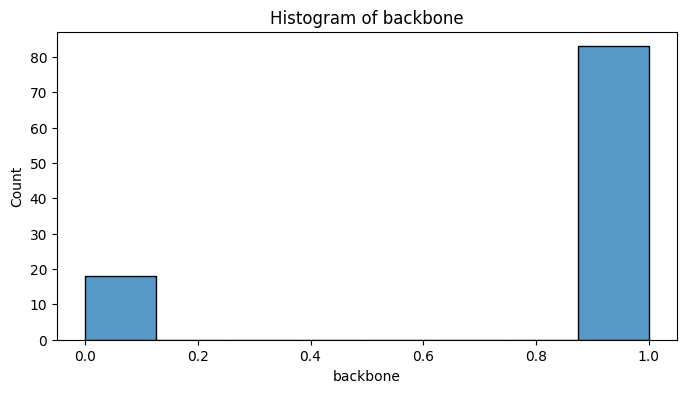

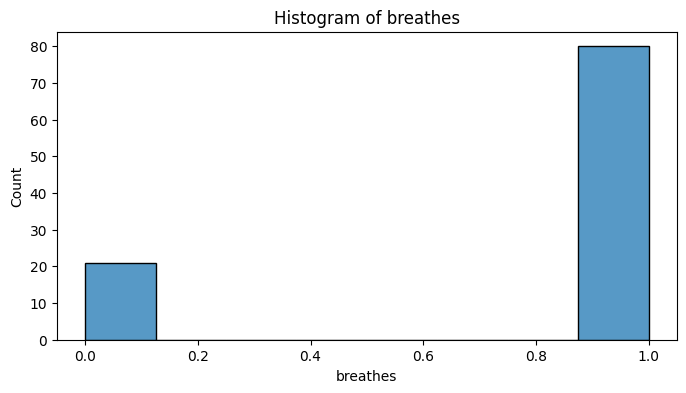

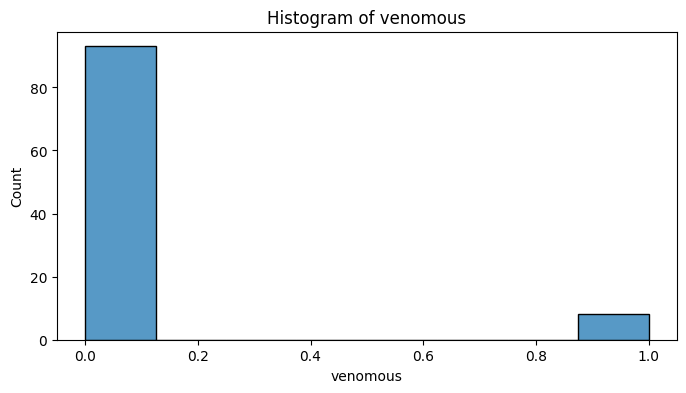

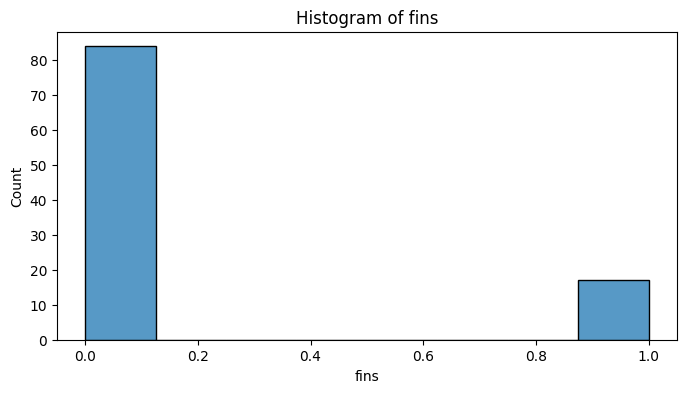

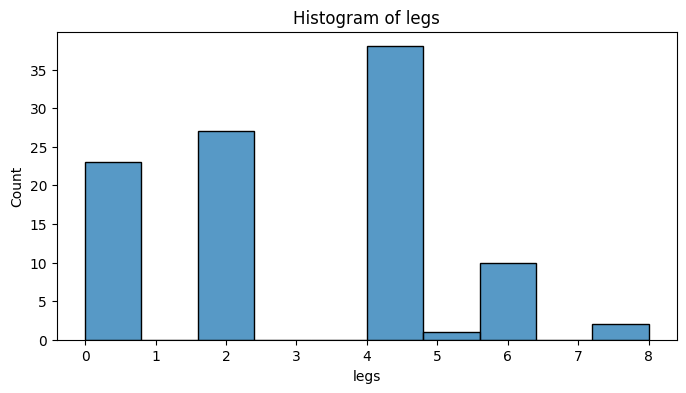

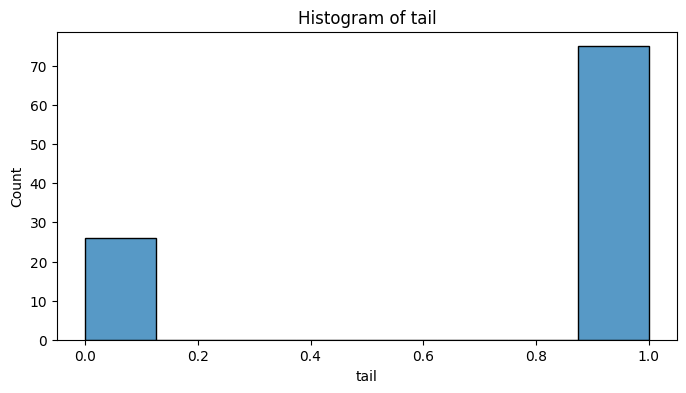

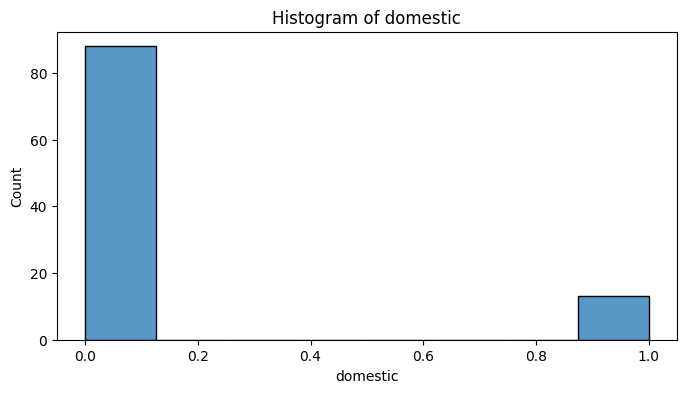

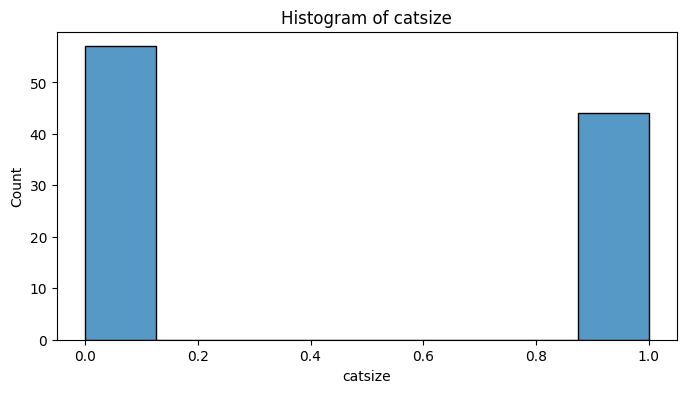

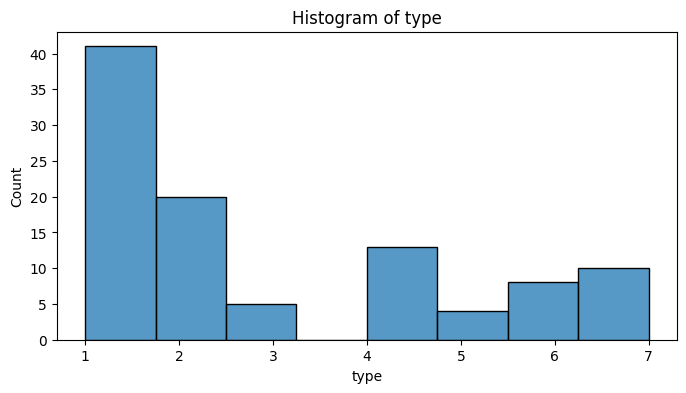

In [16]:
for col in data.columns:
  plt.figure(figsize=(8, 4))
  sns.histplot(data[col])
  plt.title(f'Histogram of {col}')
  plt.xlabel(col)
  plt.show()

In [17]:
#knn
X = data.drop('type', axis=1)
y = data['type']


from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.5,1.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,1.0,0.0,1.0


In [18]:
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
params_grid = {'n_neighbors':  np.arange(1,25)}
knn_gscv = GridSearchCV(  knn,  params_grid, cv=4)
knn_gscv.fit(X_scaled, y)
print(knn_gscv.best_params_)
print(knn_gscv.best_score_)

{'n_neighbors': np.int64(1)}
0.9503846153846154


In [19]:
y_pred = knn_gscv.predict(X_scaled)
from sklearn.metrics import accuracy_score
print(accuracy_score(y, y_pred))
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, y_pred))

1.0
[[41  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0]
 [ 0  0  5  0  0  0  0]
 [ 0  0  0 13  0  0  0]
 [ 0  0  0  0  4  0  0]
 [ 0  0  0  0  0  8  0]
 [ 0  0  0  0  0  0 10]]


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [21]:
y_pred=knn.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test,y_pred)
print('Accuracy',accuracy)

Accuracy 0.9523809523809523


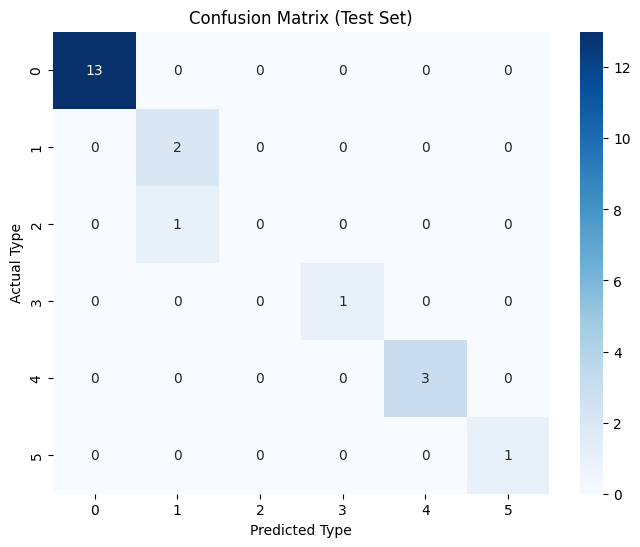

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        13
           2       0.67      1.00      0.80         2
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
from sklearn.metrics import classification_report, confusion_matrix


# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual Type')
plt.xlabel('Predicted Type')
plt.show()

# 2. Precision, Recall, F1-Score
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Decision Boundary Visualization
Because the dataset has 16 features, we cannot directly plot a 2D decision boundary. We must reduce the dimensionality using PCA to 2 dimensions to visualize how KNN divides the space.

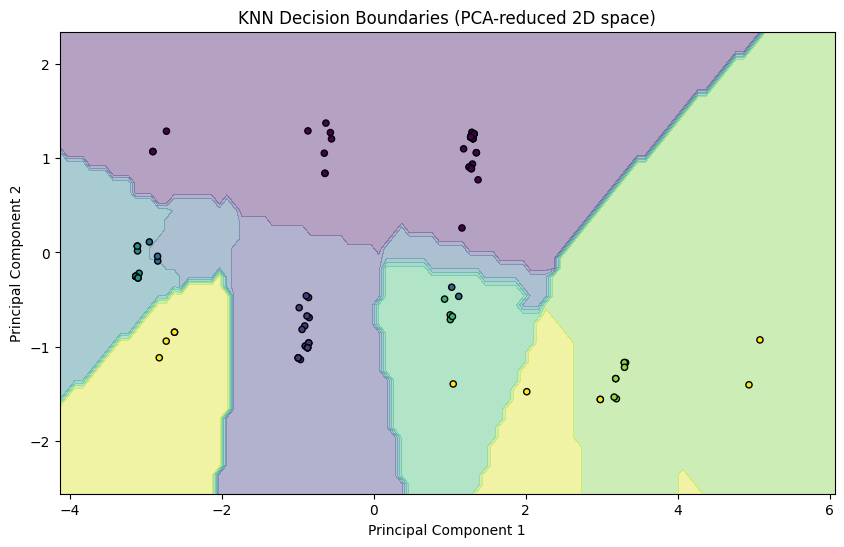

In [26]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# 1. Reduce data to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. Train a new KNN on this 2D data for visualization purposes
knn_viz = KNeighborsClassifier(n_neighbors=5) # Use your chosen k
knn_viz.fit(X_pca, y)

# 3. Create a meshgrid to plot boundaries
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# 4. Predict classifications for each point in the mesh
Z = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, edgecolor='k', cmap='viridis')
plt.title('KNN Decision Boundaries (PCA-reduced 2D space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### 1. Key Hyperparameters in KNN

The primary hyperparameter in K-Nearest Neighbors (KNN) is **`k` (the number of neighbors)**.

*   **`k` (Number of Neighbors)**: This is the most crucial hyperparameter. It determines how many nearest data points are considered when making a prediction for a new data point.
    *   **Impact**:
        *   A small `k` (e.g., k=1) makes the model highly sensitive to noise and outliers, leading to high variance and potentially overfitting. The decision boundary can be very irregular.
        *   A large `k` makes the model more robust to noise but can lead to over-smoothing of the decision boundary, blurring class distinctions, and potentially underfitting (high bias). It might also include neighbors from other classes, leading to misclassifications.
    *   **Selection**: The optimal `k` is usually found through techniques like cross-validation, where different `k` values are tested, and the one that yields the best performance on a validation set is chosen. In your notebook, `GridSearchCV` was used to find the best `n_neighbors`, and it found `1` to be the best for the training data.

### 2. Distance Metrics in KNN

KNN relies on calculating the distance between data points. The choice of distance metric can significantly impact the model's performance. Here are some commonly used distance metrics:

*   **Euclidean Distance**: This is the most common and default distance metric. It represents the shortest straight-line distance between two points in Euclidean space.
    *   **Formula (for two points p and q in n-dimensional space)**:  `sqrt(sum((p_i - q_i)^2))`
    *   **When to use**: Works well for many general-purpose applications and when the features are on a similar scale.

*   **Manhattan Distance (L1 Distance / City Block Distance)**: This metric calculates the sum of the absolute differences between the coordinates of two points. Imagine moving along a grid, like in a city block.
    *   **Formula**: `sum(abs(p_i - q_i))`
    *   **When to use**: Useful when features represent differences in different dimensions that are not directly comparable (e.g., if you have different units for each feature) or when you want to minimize the impact of large differences in single dimensions.

*   **Minkowski Distance**: This is a generalization of both Euclidean and Manhattan distances. It introduces a parameter `p`.
    *   **Formula**: `(sum(abs(p_i - q_i)^p))^(1/p)`
    *   **When to use**:
        *   When `p=1`, it becomes Manhattan distance.
        *   When `p=2`, it becomes Euclidean distance.
        *   You can tune `p` to find an optimal balance. Higher `p` values tend to be more sensitive to larger differences.

*   **Hamming Distance**: This metric is typically used for categorical or binary data. It counts the number of positions at which the corresponding symbols are different between two strings or binary vectors.
    *   **When to use**: When comparing data points with purely categorical or binary features.

*   **Cosine Similarity (or Cosine Distance)**: While often framed as similarity, it can be converted to a distance. It measures the cosine of the angle between two vectors. A cosine of 1 means the vectors are in the same direction, 0 means they are orthogonal, and -1 means they are in opposite directions.
    *   **When to use**: Particularly effective in high-dimensional spaces, like text analysis, where the magnitude of vectors is less important than their orientation.

Choosing the right distance metric depends on the nature of your data and the problem you are trying to solve.